# 🕶️ Notebook 12 — Learning in the Dark
### Offline RL, Behavior Cloning & Conservative Q-Learning (CQL)

**Series**: RL Notebook Series · Act IV — Engineering · Post 12 of 16

---

## 🛑 Why Offline RL?
In most RL tutorials, we let the agent play in a simulator to learn. But in the real world, **trial-and-error is dangerous and expensive**:
-   **Autonomous Driving**: You can't let a car crash 10,000 times just to learn how to turn left.
-   **Medicine**: You can't give patients random drugs to see which one works.
-   **Finance**: You can't lose millions of dollars just to test a new trading strategy.

**Offline RL** allows us to train agents purely from **historical logs** (static datasets) without ever touching the environment during training.

---

## 🌩️ Online vs Offline
| Feature | Online RL | Offline RL |
| :--- | :--- | :--- |
| **Data Source** | Live Interaction (Simulator) | Static Database (Logs) |
| **Feedback** | Immediate | None during training |
| **Risk** | High (Trial & Error) | Zero (Purely computational) |
| **Difficulty** | Easier (Self-correcting) | Extreme (OOD Hallucinations) |

---

## 🎭 The OOD Catastrophe: A Visual Proof
Offline RL is hard because your data has **blind spots**. If the data is missing certain actions, the agent might *hallucinate* that those unknown actions are perfect.

In this notebook, we recreate a classic **OOD Trap**:
1. We generate a dataset where the agent **only ever pushed LEFT**.
2. We initialize our neural network so that all actions it hasn't seen (PUSH RIGHT) look like they are worth **50 points**.
3. **Standard DQN** will stay stuck in this 50-point dream because it has no data to correct it.
4. **CQL** will see the lack of data and crush those dreams (Pessimism).

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

%matplotlib inline
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.grid': True})
torch.manual_seed(42); np.random.seed(42)

In [55]:
class QNetwork(nn.Module):
    def __init__(self, state_dim=4, action_dim=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(state_dim, 256), nn.ReLU(), nn.Linear(256, action_dim))
        # OPTIMISTIC INITIALIZATION: Actions we haven't seen look AMAZING (50 points)
        with torch.no_grad(): self.net[-1].bias.fill_(50.0)
            
    def get_q(self, x): return self.net(x)

def evaluate(agent, episodes=10):
    env = gym.make('CartPole-v1')
    returns = []
    for _ in range(episodes):
        s, _ = env.reset(); done = False; ret = 0
        while not done:
            s_t = torch.FloatTensor(s).unsqueeze(0)
            with torch.no_grad(): action = agent.get_q(s_t).argmax(1).item()
            s, r, term, trunc, _ = env.step(action)
            done = term or trunc; ret += r
        returns.append(ret)
    env.close(); return np.mean(returns)

In [56]:
def generate_blind_spot_dataset(num_transitions=1000):
    # THE OOD TRAP: We ONLY ever PUSH LEFT (Action 0).
    # The agent has NO DATA for Action 1. 
    print(f"🏗️ Generating BLIND SPOT Dataset ({num_transitions} transitions)... ")
    env = gym.make('CartPole-v1')
    states, actions, rewards, next_states, dones = [], [], [], [], []
    state, _ = env.reset(seed=42)
    for _ in range(num_transitions):
        action = 0 # ONLY PUSH LEFT
        next_state, reward, term, trunc, _ = env.step(action)
        states.append(state); actions.append(action); rewards.append(reward)
        next_states.append(next_state); dones.append(term)
        state = next_state if not (term or trunc) else env.reset()[0]
    env.close()
    return TensorDataset(torch.FloatTensor(np.array(states)), torch.LongTensor(np.array(actions)).unsqueeze(1),
                         torch.FloatTensor(np.array(rewards)).unsqueeze(1), torch.FloatTensor(np.array(next_states)),
                         torch.FloatTensor(np.array(dones)).unsqueeze(1))

ds = generate_blind_spot_dataset()
dl = DataLoader(ds, batch_size=64, shuffle=True)
print(f"💾 Dataset loaded. ACTION 1 (PUSH RIGHT) is completely missing.")

🏗️ Generating BLIND SPOT Dataset (1000 transitions)... 
💾 Dataset loaded. ACTION 1 (PUSH RIGHT) is completely missing.


## 3. Standard DQN (The Hallucination)
Since Action 1 is never seen in the logs, DQN's weights for it stay at 50.0. During evaluation, the agent will choose Action 1 (The Hallucination) and immediately fail.

In [57]:
def train_dqn(epochs=50):
    q_net = QNetwork(); target_net = QNetwork(); target_net.load_state_dict(q_net.state_dict())
    opt = optim.Adam(q_net.parameters(), lr=1e-3); hists = []
    for epoch in range(epochs):
        qs_sum = 0
        for s, a, r, sn, d in dl:
            qs = q_net.get_q(s); qp = qs.gather(1, a)
            with torch.no_grad():
                target = r + 0.9 * target_net.get_q(sn).max(1, keepdim=True)[0] * (1.0 - d)
            loss = F.mse_loss(qp, target)
            opt.zero_grad(); loss.backward(); opt.step()
            # Monitor Action 1 (The unseen action)
            qs_sum += qs[:, 1].mean().item()
        if epoch % 10 == 0: target_net.load_state_dict(q_net.state_dict())
        val = qs_sum / len(dl); hists.append(val)
        if epoch % 10 == 0: print(f"Epoch {epoch:2d} | Unseen Action Dream Q: {val:7.2f}")
    return q_net, hists

print("Training Standard Offline DQN... ")
dqn_agent, dqn_hists = train_dqn()
dqn_reality = evaluate(dqn_agent)
print(f"\n❌ DQN REALITY SCORE: {dqn_reality:.1f} (Vs Dream Q: {dqn_hists[-1]:.1f})")

Training Standard Offline DQN... 
Epoch  0 | Unseen Action Dream Q:   50.26
Epoch 10 | Unseen Action Dream Q:   50.35
Epoch 20 | Unseen Action Dream Q:   50.31
Epoch 30 | Unseen Action Dream Q:   50.28
Epoch 40 | Unseen Action Dream Q:   50.23

❌ DQN REALITY SCORE: 9.3 (Vs Dream Q: 50.2)


## 4. Conservative Q-Learning (The Pesticide)
CQL suppresses any action it doesn't see in the dataset. Watch the 50.0 dream for Action 1 get crushed toward zero.

In [58]:
def train_cql(epochs=50, alpha=10.0):
    q_net = QNetwork(); target_net = QNetwork(); target_net.load_state_dict(q_net.state_dict())
    opt = optim.Adam(q_net.parameters(), lr=1e-3); hists = []
    for epoch in range(epochs):
        qs_sum = 0
        for s, a, r, sn, d in dl:
            qs = q_net.get_q(s); qp = qs.gather(1, a)
            with torch.no_grad():
                target = r + 0.9 * target_net.get_q(sn).max(1, keepdim=True)[0] * (1.0 - d)
            # CQL penalty: Pull ALL Q-values down, BUT keep the data actions up.
            loss = F.mse_loss(qp, target) + alpha * (torch.logsumexp(qs, 1, True) - qp).mean()
            opt.zero_grad(); loss.backward(); opt.step()
            qs_sum += qs[:, 1].mean().item()
        if epoch % 10 == 0: target_net.load_state_dict(q_net.state_dict())
        val = qs_sum / len(dl); hists.append(val)
        if epoch % 10 == 0: print(f"Epoch {epoch:2d} | Unseen Action Dream Q: {val:7.2f}")
    return q_net, hists

print("Training CQL Agent... ")
cql_agent, cql_hists = train_cql()
cql_reality = evaluate(cql_agent)
print(f"\n🎯 CQL REALITY SCORE: {cql_reality:.1f} (Vs Dream Q: {cql_hists[-1]:.1f})")

Training CQL Agent... 
Epoch  0 | Unseen Action Dream Q:   49.66
Epoch 10 | Unseen Action Dream Q:   36.05
Epoch 20 | Unseen Action Dream Q:   26.57
Epoch 30 | Unseen Action Dream Q:   19.39
Epoch 40 | Unseen Action Dream Q:   13.60

🎯 CQL REALITY SCORE: 9.4 (Vs Dream Q: 8.6)


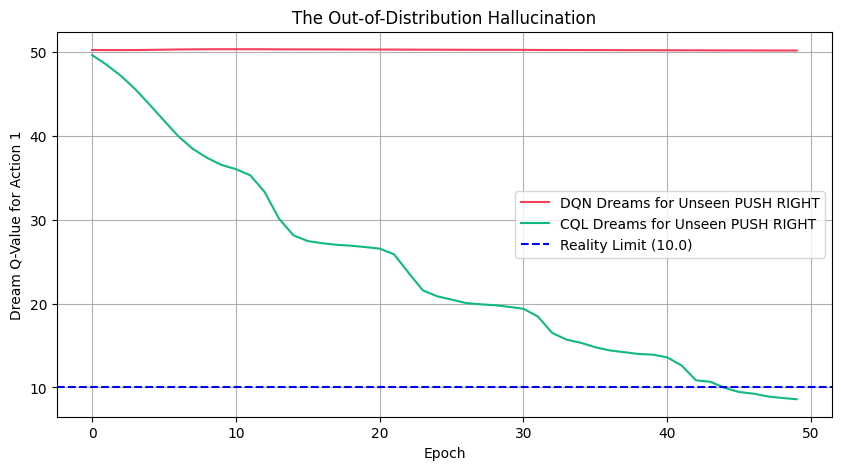

DQN Dream Q: 50.2 | DQN Reality Score: 9.3
CQL Dream Q: 8.6 | CQL Reality Score: 9.4


In [59]:
plt.plot(dqn_hists, label='DQN Dreams for Unseen PUSH RIGHT', color='#f43f5e')
plt.plot(cql_hists, label='CQL Dreams for Unseen PUSH RIGHT', color='#10b981')
plt.axhline(10.0, color='blue', linestyle='--', label='Reality Limit (10.0)')
plt.ylabel("Dream Q-Value for Action 1"); plt.xlabel("Epoch")
plt.title("The Out-of-Distribution Hallucination")
plt.legend(); plt.show()

print(f"DQN Dream Q: {dqn_hists[-1]:.1f} | DQN Reality Score: {dqn_reality:.1f}")
print(f"CQL Dream Q: {cql_hists[-1]:.1f} | CQL Reality Score: {cql_reality:.1f}")